# Room Occupancy Classification

Test GPU : True → GPU activé ✅
False → GPU NON activé ❌

In [ ]:
import torch
print(torch.cuda.is_available())

True


Paramètre au dessus de 3h

In [ ]:
# -----------------------------
# 4. User-tunable config (FAST ~1H VERSION)
# -----------------------------
SEEDS = [42]
N_FOLDS = 5

MAX_EPOCHS = 70
PATIENCE = 12
BATCH_SIZE = 256
PRED_BATCH_SIZE = 512
NUM_WORKERS = 2

TTA_PASSES = 4
LABEL_SMOOTHING = 0.05
PSEUDO_CONF = 0.997
USE_PSEUDO_LABELING = True
MIN_PSEUDO_SAMPLES = 30

MODEL_CONFIGS = [
    ("ResCNNLite", 1.1e-3, 5e-4),
    ("SEDeepCNN", 8.5e-4, 5e-4),
]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RUNTIME INFORMATION
PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
Extracting x_train.zip...
Extraction completed.
Extracting x_test.zip...
Extraction completed.

DATASET OVERVIEW
Training CSV shape: (9227, 2)
Test template shape: (3955, 2)
Training images: 9227
Test images: 3955

Class distribution:
target
0    1462
1    3786
2    3002
3     977
Name: count, dtype: int64

Loading images into memory...
Training tensor: (9227, 3, 45, 51)
Test tensor: (3955, 3, 45, 51)
Loading and normalization completed in 7.8 seconds

ROUND 1 - CROSS-VALIDATION TRAINING

----------------------------------------------------------------------
Run 1/10: CompactResidualCNN | seed 42 | fold 1/5
----------------------------------------------------------------------

Training CompactResidualCNN | seed 42 | fold 1/5
  Epoch 001 | val_acc=0.62622 | best=0.62622 | improved
  

,round,model,seed,fold,best_val_accuracy,epochs_trained
0,Round 1,CompactResidualCNN,42,1,0.964789,61
1,Round 1,CompactResidualCNN,42,2,0.966956,68
2,Round 1,CompactResidualCNN,42,3,0.962060,54
3,Round 1,CompactResidualCNN,42,4,0.969648,70
4,Round 1,CompactResidualCNN,42,5,0.963144,70
5,Round 1,AttentionResidualCNN,42,1,0.965872,67
6,Round 1,AttentionResidualCNN,42,2,0.970748,70
7,Round 1,AttentionResidualCNN,42,3,0.950136,33
8,Round 1,AttentionResidualCNN,42,4,0.970190,70
9,Round 1,AttentionResidualCNN,42,5,0.964770,59



Grouped validation performance:


,round,model,mean,std,min,max,count
0,Round 1,AttentionResidualCNN,0.964343,0.008360,0.950136,0.970748,5
1,Round 1,CompactResidualCNN,0.965319,0.003044,0.962060,0.969648,5



Prediction distribution:


,count
target,
0,598
1,1644
2,1297
3,416


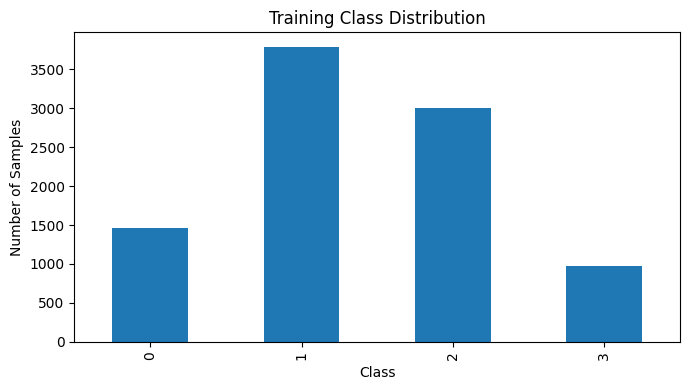

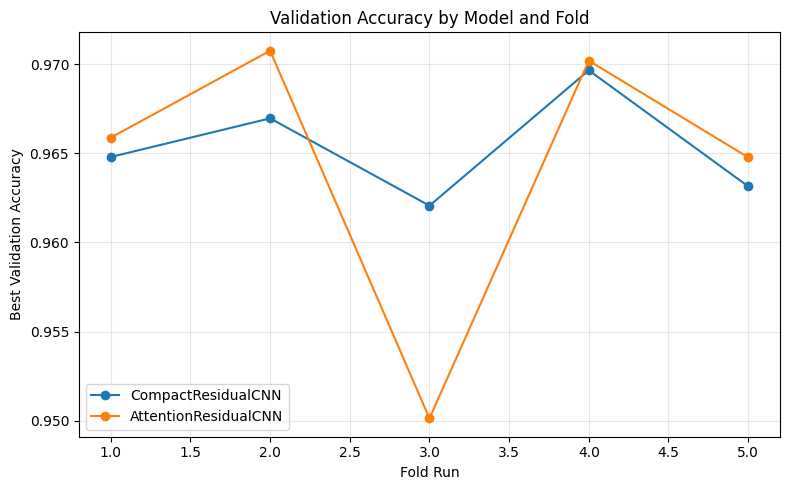

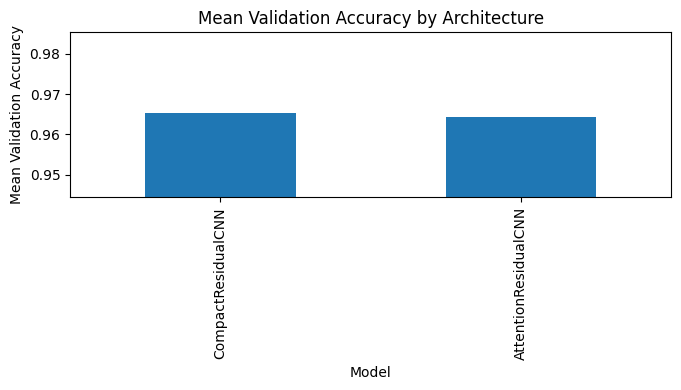

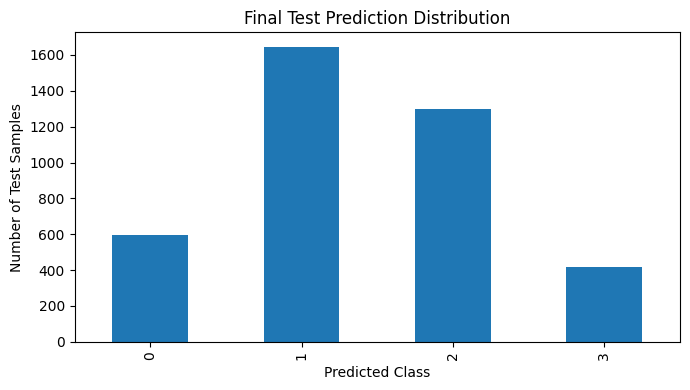

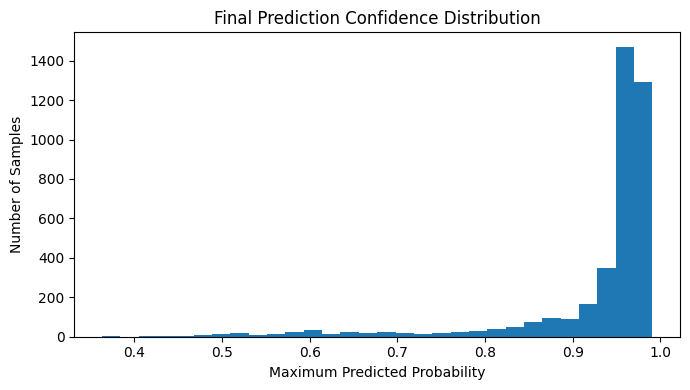

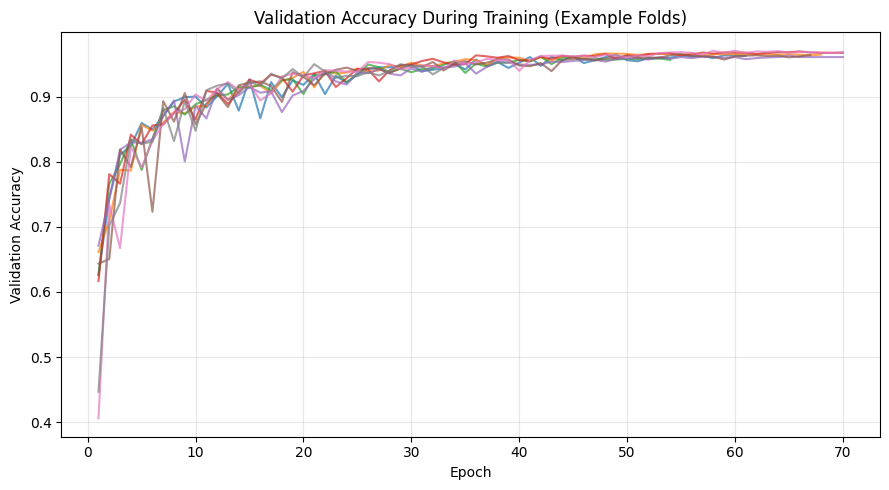


PIPELINE COMPLETED
Total running time: 24.0 minutes
Round 1 mean validation accuracy: 0.96483

Generated files:
- /content/submission.csv
- /content/submission_round1.csv
- /content/drive/MyDrive/map_mlf_outputs/validation_summary.csv
- /content/drive/MyDrive/map_mlf_outputs/training_history.csv
- /content/drive/MyDrive/map_mlf_outputs/figure_*.png

Use /content/submission.csv or /content/drive/MyDrive/submission.csv for Kaggle.


In [2]:
# ============================================================
# Room Occupancy Classification - MAP-MLF Final Project
# Complete Google Colab Pipeline
# ============================================================

# ============================================================
# 1. Google Drive Mount
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from google.colab import files

files.download('/content/submission.csv')
files.download('/content/submission_round1.csv')


# ============================================================
# 2. Imports
# ============================================================

import os
import gc
import time
import random
import zipfile
import warnings
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings("ignore")


# ============================================================
# 3. Reproducibility
# ============================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# ============================================================
# 4. Paths and Runtime Configuration
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks"

TRAIN_ZIP = os.path.join(BASE_DIR, "x_train.zip")
TEST_ZIP = os.path.join(BASE_DIR, "x_test.zip")
TRAIN_CSV = os.path.join(BASE_DIR, "y_train_v2.csv")
TEST_TEMPLATE_CSV = os.path.join(BASE_DIR, "y_test_submission_example_v2.csv")

WORK_DIR = "/content/map_mlf_project"
TRAIN_DIR = os.path.join(WORK_DIR, "train_images")
TEST_DIR = os.path.join(WORK_DIR, "test_images")

OUTPUT_DIR = "/content/drive/MyDrive/map_mlf_outputs"
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

print("=" * 70)
print("RUNTIME INFORMATION")
print("=" * 70)
print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Warning: GPU is not active. Training will be slow.")


# ============================================================
# 5. Training Parameters
# ============================================================

SEEDS = [42]
N_FOLDS = 5

MAX_EPOCHS = 70
PATIENCE = 12

BATCH_SIZE = 256
PRED_BATCH_SIZE = 512
NUM_WORKERS = 2

TTA_PASSES = 4
LABEL_SMOOTHING = 0.05

USE_PSEUDO_LABELING = True
PSEUDO_CONF = 0.997
MIN_PSEUDO_SAMPLES = 30

MODEL_CONFIGS = [
    ("CompactResidualCNN", 1.1e-3, 5e-4),
    ("AttentionResidualCNN", 8.5e-4, 5e-4),
]


# ============================================================
# 6. Dataset Preparation
# ============================================================

for path in [TRAIN_ZIP, TEST_ZIP, TRAIN_CSV, TEST_TEMPLATE_CSV]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

def extract_zip_if_needed(zip_path, output_folder):
    existing_images = [f for f in os.listdir(output_folder) if f.endswith(".png")]
    if len(existing_images) > 100:
        print(f"Dataset already extracted: {len(existing_images)} images found in {output_folder}")
        return

    print(f"Extracting {os.path.basename(zip_path)}...")
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(output_folder)
    print("Extraction completed.")

extract_zip_if_needed(TRAIN_ZIP, TRAIN_DIR)
extract_zip_if_needed(TEST_ZIP, TEST_DIR)

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_TEMPLATE_CSV)

print("\n" + "=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print("Training CSV shape:", train_df.shape)
print("Test template shape:", test_df.shape)
print("Training images:", len([f for f in os.listdir(TRAIN_DIR) if f.endswith(".png")]))
print("Test images:", len([f for f in os.listdir(TEST_DIR) if f.endswith(".png")]))
print("\nClass distribution:")
print(train_df["target"].value_counts().sort_index())


# ============================================================
# 7. Image Loading
# ============================================================

def image_path_from_id(image_id: int, is_test: bool) -> str:
    file_name = f"img_{int(image_id) + 1}.png"
    folder = TEST_DIR if is_test else TRAIN_DIR
    return os.path.join(folder, file_name)

def load_image_as_tensor(path: str) -> np.ndarray:
    image = np.array(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0
    image = np.transpose(image, (2, 0, 1))
    return image

def load_image_set(ids, is_test: bool) -> np.ndarray:
    images = []
    for image_id in ids:
        path = image_path_from_id(image_id, is_test=is_test)
        images.append(load_image_as_tensor(path))
    return np.stack(images, axis=0)

print("\nLoading images into memory...")
start = time.time()

X_all = load_image_set(train_df["id"].values, is_test=False)
y_all = train_df["target"].values.astype(np.int64)
X_test = load_image_set(test_df["id"].values, is_test=True)

mean = X_all.mean(axis=(0, 2, 3), keepdims=True)
std = X_all.std(axis=(0, 2, 3), keepdims=True) + 1e-7

X_all = (X_all - mean) / std
X_test = (X_test - mean) / std

N_CLASSES = len(np.unique(y_all))

print("Training tensor:", X_all.shape)
print("Test tensor:", X_test.shape)
print(f"Loading and normalization completed in {time.time() - start:.1f} seconds")


# ============================================================
# 8. Dataset Class
# ============================================================

class RadarImageDataset(Dataset):
    def __init__(self, X, y=None, augment=False):
        self.X = torch.from_numpy(X.astype(np.float32))
        self.y = None if y is None else torch.from_numpy(y.astype(np.int64))
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        x = self.X[index].clone()

        if self.augment:
            if torch.rand(1).item() > 0.5:
                x = x.flip(2)
            if torch.rand(1).item() > 0.5:
                x = x.flip(1)

        if self.y is None:
            return x

        return x, self.y[index]


# ============================================================
# 9. Neural Network Blocks
# ============================================================

class ChannelAttentionBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden_units = max(channels // reduction, 4)

        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, hidden_units, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_units, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.attention(x).unsqueeze(-1).unsqueeze(-1)
        return x * weights


class ResidualConvBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv_a = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn_a = nn.BatchNorm2d(channels)

        self.conv_b = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn_b = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn_a(self.conv_a(x)), inplace=True)
        x = self.bn_b(self.conv_b(x))
        return F.relu(x + residual, inplace=True)


# ============================================================
# 10. Model Architectures
# ============================================================

class CompactResidualCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            ResidualConvBlock(32),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),

            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualConvBlock(64),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.12),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResidualConvBlock(128),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Dropout2d(0.18),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.classifier(x)


class AttentionResidualCNN(nn.Module):
    def __init__(self, n_classes=4):
        super().__init__()

        self.stage_1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            ResidualConvBlock(32),
            ChannelAttentionBlock(32),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),
        )

        self.stage_2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResidualConvBlock(64),
            ChannelAttentionBlock(64),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.12),
        )

        self.stage_3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResidualConvBlock(128),
            ChannelAttentionBlock(128),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.16),
        )

        self.stage_4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            ResidualConvBlock(256),
            ChannelAttentionBlock(256),
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Dropout2d(0.20),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 384),
            nn.BatchNorm1d(384),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(384, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.stage_1(x)
        x = self.stage_2(x)
        x = self.stage_3(x)
        x = self.stage_4(x)
        return self.classifier(x)


def create_model(model_name):
    if model_name == "CompactResidualCNN":
        return CompactResidualCNN(N_CLASSES)
    if model_name == "AttentionResidualCNN":
        return AttentionResidualCNN(N_CLASSES)
    raise ValueError(f"Unknown model name: {model_name}")


# ============================================================
# 11. Training and Prediction Functions
# ============================================================

def clean_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def train_fold(model_name, learning_rate, weight_decay, X_train, y_train, X_val, y_val, fold_label):
    train_dataset = RadarImageDataset(X_train, y_train, augment=True)
    val_dataset = RadarImageDataset(X_val, y_val, augment=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=PRED_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    model = create_model(model_name).to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)
    scaler = GradScaler(enabled=USE_AMP)

    best_accuracy = 0.0
    best_weights = None
    epochs_without_improvement = 0

    epoch_records = []

    print(f"\nTraining {fold_label}")

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_start = time.time()
        model.train()

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(enabled=USE_AMP):
                logits = model(batch_x)
                loss = criterion(logits, batch_y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(DEVICE, non_blocking=True)
                batch_y = batch_y.to(DEVICE, non_blocking=True)

                with autocast(enabled=USE_AMP):
                    logits = model(batch_x)

                predictions = logits.argmax(dim=1)
                correct += (predictions == batch_y).sum().item()
                total += len(batch_y)

        val_accuracy = correct / max(total, 1)
        scheduler.step()

        improved = val_accuracy > best_accuracy

        if improved:
            best_accuracy = val_accuracy
            best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        epoch_records.append({
            "fold": fold_label,
            "epoch": epoch,
            "val_accuracy": val_accuracy,
            "best_accuracy": best_accuracy,
            "epoch_time_sec": time.time() - epoch_start
        })

        if epoch == 1 or improved or epoch % 10 == 0:
            status = "improved" if improved else "no improvement"
            print(
                f"  Epoch {epoch:03d} | "
                f"val_acc={val_accuracy:.5f} | "
                f"best={best_accuracy:.5f} | "
                f"{status}"
            )

        if epochs_without_improvement >= PATIENCE:
            print(f"  Early stopping after {epoch} epochs")
            break

    del model
    clean_memory()

    return best_weights, best_accuracy, epoch_records


def predict_with_flip_tta(model_name, model_weights, X):
    model = create_model(model_name).to(DEVICE)
    model.load_state_dict(model_weights)
    model.eval()

    probability_sets = []

    for tta_id in range(TTA_PASSES):
        X_tensor = torch.from_numpy(X.astype(np.float32)).clone()

        if tta_id % 4 == 1:
            X_tensor = X_tensor.flip(3)
        elif tta_id % 4 == 2:
            X_tensor = X_tensor.flip(2)
        elif tta_id % 4 == 3:
            X_tensor = X_tensor.flip(2).flip(3)

        prediction_loader = DataLoader(
            TensorDataset(X_tensor),
            batch_size=PRED_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available()
        )

        batch_probabilities = []

        with torch.no_grad():
            for (batch_x,) in prediction_loader:
                batch_x = batch_x.to(DEVICE, non_blocking=True)

                with autocast(enabled=USE_AMP):
                    logits = model(batch_x)
                    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

                batch_probabilities.append(probabilities)

        probability_sets.append(np.concatenate(batch_probabilities, axis=0))

        del X_tensor, prediction_loader, batch_probabilities
        clean_memory()

    del model
    clean_memory()

    return np.mean(probability_sets, axis=0)


# ============================================================
# 12. Cross-Validation Training - Round 1
# ============================================================

print("\n" + "=" * 70)
print("ROUND 1 - CROSS-VALIDATION TRAINING")
print("=" * 70)

round1_models = []
round1_scores = []
training_history = []
fold_summary = []

total_runs = len(MODEL_CONFIGS) * len(SEEDS) * N_FOLDS
current_run = 0
global_start_time = time.time()

for model_name, lr, weight_decay in MODEL_CONFIGS:
    for seed in SEEDS:
        set_seed(seed)

        splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

        for fold_number, (train_index, val_index) in enumerate(splitter.split(X_all, y_all), start=1):
            current_run += 1

            fold_label = f"{model_name} | seed {seed} | fold {fold_number}/{N_FOLDS}"
            print("\n" + "-" * 70)
            print(f"Run {current_run}/{total_runs}: {fold_label}")
            print("-" * 70)

            weights, score, epoch_records = train_fold(
                model_name=model_name,
                learning_rate=lr,
                weight_decay=weight_decay,
                X_train=X_all[train_index],
                y_train=y_all[train_index],
                X_val=X_all[val_index],
                y_val=y_all[val_index],
                fold_label=fold_label
            )

            round1_models.append((model_name, weights))
            round1_scores.append(score)
            training_history.extend(epoch_records)

            fold_summary.append({
                "round": "Round 1",
                "model": model_name,
                "seed": seed,
                "fold": fold_number,
                "best_val_accuracy": score,
                "epochs_trained": len(epoch_records)
            })

            print(f"Best validation accuracy for this fold: {score:.5f}")

            clean_memory()

round1_time = (time.time() - global_start_time) / 60
print("\nRound 1 completed.")
print(f"Mean validation accuracy: {np.mean(round1_scores):.5f}")
print(f"Best validation accuracy: {np.max(round1_scores):.5f}")
print(f"Time elapsed: {round1_time:.1f} minutes")


# ============================================================
# 13. Round 1 Test Prediction
# ============================================================

print("\n" + "=" * 70)
print("ROUND 1 - TEST PREDICTION WITH TTA")
print("=" * 70)

round1_probability_list = []

for model_id, (model_name, weights) in enumerate(round1_models, start=1):
    print(f"Predicting with model {model_id}/{len(round1_models)}: {model_name}")
    probabilities = predict_with_flip_tta(model_name, weights, X_test)
    round1_probability_list.append(probabilities)

round1_probabilities = np.mean(round1_probability_list, axis=0)
round1_predictions = np.argmax(round1_probabilities, axis=1)
round1_confidence = np.max(round1_probabilities, axis=1)

submission_round1 = pd.DataFrame({
    "id": test_df["id"].values,
    "target": round1_predictions
})

submission_round1.to_csv("/content/submission_round1.csv", index=False)
submission_round1.to_csv(os.path.join(OUTPUT_DIR, "submission_round1.csv"), index=False)

print("Round 1 submission saved.")


# ============================================================
# 14. Optional Pseudo-Labeling - Round 2
# ============================================================

final_predictions = round1_predictions
final_probabilities = round1_probabilities

if USE_PSEUDO_LABELING:
    print("\n" + "=" * 70)
    print("ROUND 2 - PSEUDO-LABELING")
    print("=" * 70)

    pseudo_mask = round1_confidence >= PSEUDO_CONF
    pseudo_count = int(pseudo_mask.sum())

    print(f"Confidence threshold: {PSEUDO_CONF}")
    print(f"Pseudo-labeled test samples selected: {pseudo_count}")

    if pseudo_count >= MIN_PSEUDO_SAMPLES:
        pseudo_X = X_test[pseudo_mask]
        pseudo_y = round1_predictions[pseudo_mask]

        print("Pseudo-label distribution:", np.bincount(pseudo_y, minlength=N_CLASSES))

        round2_models = []
        round2_scores = []
        round2_probability_list = []

        total_runs_round2 = len(MODEL_CONFIGS) * len(SEEDS) * N_FOLDS
        current_run = 0

        for model_name, lr, weight_decay in MODEL_CONFIGS:
            for seed in SEEDS:
                set_seed(seed + 10_000)

                splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed + 10_000)

                for fold_number, (train_index, val_index) in enumerate(splitter.split(X_all, y_all), start=1):
                    current_run += 1

                    fold_label = f"R2 {model_name} | seed {seed} | fold {fold_number}/{N_FOLDS}"
                    print("\n" + "-" * 70)
                    print(f"Round 2 run {current_run}/{total_runs_round2}: {fold_label}")
                    print("-" * 70)

                    X_train_combined = np.concatenate([X_all[train_index], pseudo_X], axis=0)
                    y_train_combined = np.concatenate([y_all[train_index], pseudo_y], axis=0)

                    weights, score, epoch_records = train_fold(
                        model_name=model_name,
                        learning_rate=lr,
                        weight_decay=weight_decay,
                        X_train=X_train_combined,
                        y_train=y_train_combined,
                        X_val=X_all[val_index],
                        y_val=y_all[val_index],
                        fold_label=fold_label
                    )

                    round2_models.append((model_name, weights))
                    round2_scores.append(score)
                    training_history.extend(epoch_records)

                    fold_summary.append({
                        "round": "Round 2",
                        "model": model_name,
                        "seed": seed,
                        "fold": fold_number,
                        "best_val_accuracy": score,
                        "epochs_trained": len(epoch_records)
                    })

                    clean_memory()

        print("\nRound 2 completed.")
        print(f"Round 2 mean validation accuracy: {np.mean(round2_scores):.5f}")

        print("\nPredicting with Round 2 models...")

        for model_id, (model_name, weights) in enumerate(round2_models, start=1):
            print(f"Predicting with Round 2 model {model_id}/{len(round2_models)}: {model_name}")
            probabilities = predict_with_flip_tta(model_name, weights, X_test)
            round2_probability_list.append(probabilities)

        round2_probabilities = np.mean(round2_probability_list, axis=0)
        final_probabilities = np.mean(round1_probability_list + round2_probability_list, axis=0)
        final_predictions = np.argmax(final_probabilities, axis=1)

    else:
        print("Not enough confident pseudo-labels. Final prediction uses Round 1 only.")


# ============================================================
# 15. Final Submission
# ============================================================

submission_final = pd.DataFrame({
    "id": test_df["id"].values,
    "target": final_predictions
})

submission_final.to_csv("/content/submission.csv", index=False)
submission_final.to_csv(os.path.join(OUTPUT_DIR, "submission.csv"), index=False)
shutil.copy("/content/submission.csv", "/content/drive/MyDrive/submission.csv")

print("\nFinal submission saved:")
print("- /content/submission.csv")
print("- /content/drive/MyDrive/submission.csv")


# ============================================================
# 16. Results Tables and Visualizations
# ============================================================

summary_df = pd.DataFrame(fold_summary)
history_df = pd.DataFrame(training_history)

summary_path = os.path.join(OUTPUT_DIR, "validation_summary.csv")
history_path = os.path.join(OUTPUT_DIR, "training_history.csv")

summary_df.to_csv(summary_path, index=False)
history_df.to_csv(history_path, index=False)

print("\n" + "=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

display(summary_df)

grouped_summary = (
    summary_df
    .groupby(["round", "model"])["best_val_accuracy"]
    .agg(["mean", "std", "min", "max", "count"])
    .reset_index()
)

print("\nGrouped validation performance:")
display(grouped_summary)

print("\nPrediction distribution:")
prediction_distribution = submission_final["target"].value_counts().sort_index()
display(prediction_distribution.to_frame(name="count"))


# Figure 1: Training class distribution
plt.figure(figsize=(7, 4))
train_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_class_distribution.png"), dpi=150)
plt.show()


# Figure 2: Validation score by model
plt.figure(figsize=(8, 5))
for model_name in summary_df["model"].unique():
    model_scores = summary_df[summary_df["model"] == model_name]["best_val_accuracy"].values
    plt.plot(range(1, len(model_scores) + 1), model_scores, marker="o", label=model_name)

plt.title("Validation Accuracy by Model and Fold")
plt.xlabel("Fold Run")
plt.ylabel("Best Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_validation_scores.png"), dpi=150)
plt.show()


# Figure 3: Average validation accuracy by architecture
mean_scores = summary_df.groupby("model")["best_val_accuracy"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
mean_scores.plot(kind="bar")
plt.title("Mean Validation Accuracy by Architecture")
plt.xlabel("Model")
plt.ylabel("Mean Validation Accuracy")
plt.ylim(max(0.80, mean_scores.min() - 0.02), min(1.0, mean_scores.max() + 0.02))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_mean_accuracy_by_model.png"), dpi=150)
plt.show()


# Figure 4: Final prediction distribution
plt.figure(figsize=(7, 4))
submission_final["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Final Test Prediction Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Number of Test Samples")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_prediction_distribution.png"), dpi=150)
plt.show()


# Figure 5: Confidence distribution
final_confidence = np.max(final_probabilities, axis=1)

plt.figure(figsize=(7, 4))
plt.hist(final_confidence, bins=30)
plt.title("Final Prediction Confidence Distribution")
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figure_confidence_distribution.png"), dpi=150)
plt.show()


# Figure 6: Epoch progression for validation accuracy
if not history_df.empty:
    plt.figure(figsize=(9, 5))
    for fold_name in history_df["fold"].unique()[:8]:
        subset = history_df[history_df["fold"] == fold_name]
        plt.plot(subset["epoch"], subset["val_accuracy"], alpha=0.7)

    plt.title("Validation Accuracy During Training (Example Folds)")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "figure_training_curves.png"), dpi=150)
    plt.show()


# ============================================================
# 17. Final Information
# ============================================================

total_time = (time.time() - global_start_time) / 60

print("\n" + "=" * 70)
print("PIPELINE COMPLETED")
print("=" * 70)
print(f"Total running time: {total_time:.1f} minutes")
print(f"Round 1 mean validation accuracy: {np.mean(round1_scores):.5f}")

if "round2_scores" in locals() and len(round2_scores) > 0:
    print(f"Round 2 mean validation accuracy: {np.mean(round2_scores):.5f}")

print("\nGenerated files:")
print("- /content/submission.csv")
print("- /content/submission_round1.csv")
print(f"- {summary_path}")
print(f"- {history_path}")
print(f"- {OUTPUT_DIR}/figure_*.png")
print("\nUse /content/submission.csv or /content/drive/MyDrive/submission.csv for Kaggle.")